In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


**Data wrangling!**

In [2]:
df = pd.read_csv("/kaggle/input/student-performance-multiple-linear-regression/Student_Performance.csv")

In [3]:
df.head(2)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0


In [4]:
df.shape

(10000, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
df.duplicated().sum()

127

In [7]:
df.drop_duplicates(inplace=True)


**Let's look at the distribution of the explanatory variable.**

In [8]:
fig = px.box(df["Performance Index"])
fig.update_layout(title="Distribuition of Perfomance Index")
fig.show()

In [9]:
fig = px.histogram(df["Performance Index"],color=df["Hours Studied"])
fig.update_layout(title="Distribuition of Perfomance Index by Hours Studied")

**Let's see the correlation**

In [10]:
df["Extracurricular Activities"].replace({"Yes": 1, "No": 0}, inplace=True)


/tmp/ipykernel_13/2480408668.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_13/2480408668.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



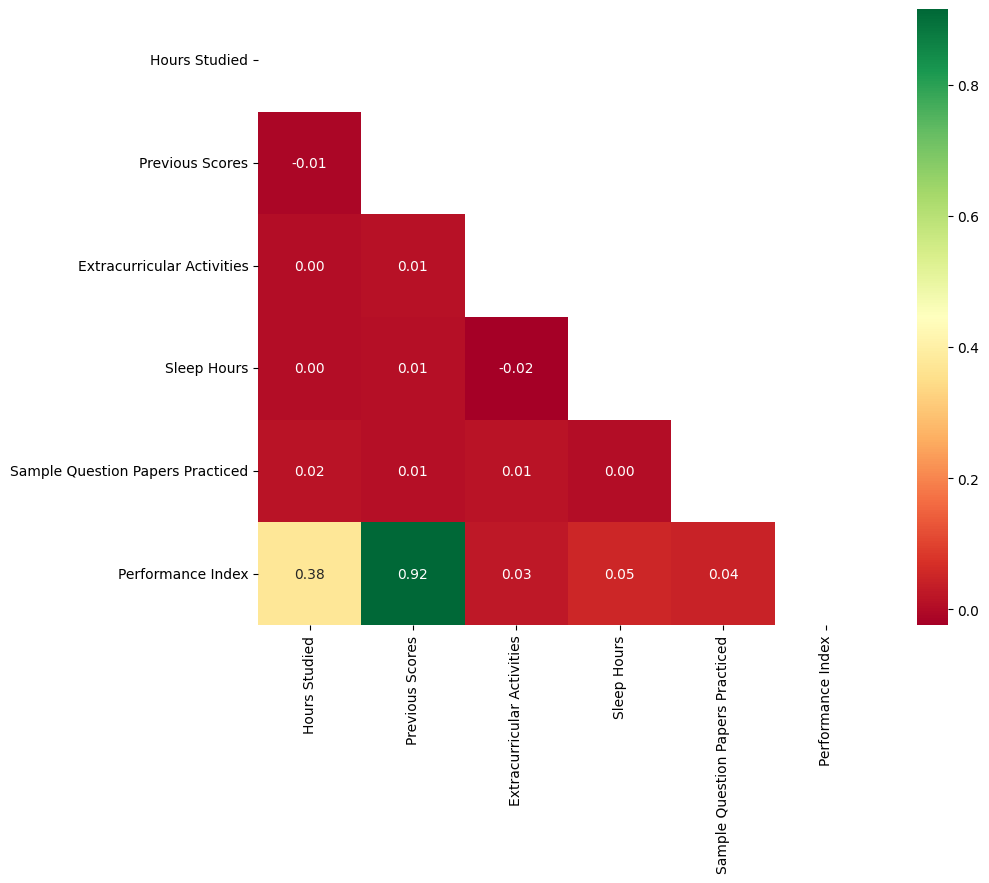

In [11]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap="RdYlGn", annot=True,fmt=".2f")
plt.show()

In [12]:
df.shape[1]

6

In [13]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=2, cols=3
)

fig.add_trace(
    go.Scatter(x=df["Previous Scores"], y=df["Performance Index"], mode='markers'),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df["Hours Studied"], y=df["Performance Index"], mode='markers'),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(x=df["Extracurricular Activities"], y=df["Performance Index"], mode='markers'),
    row=1, col=3
)

fig.add_trace(
    go.Scatter(x=df["Sample Question Papers Practiced"], y=df["Performance Index"], mode='markers'),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=df["Sleep Hours"], y=df["Performance Index"], mode='markers'),
    row=2, col=2
)

fig.update_layout(
    showlegend=False,
    height=800,
    width=1000,
    title="Linear Relationships"
)

fig.show()


**Starting Linear Regression**

In [14]:
X = df.drop(["Performance Index"],axis = 1)
y = df["Performance Index"]

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train,y_train)

LinearRegression()

In [18]:
y_predict = model.predict(X_test)

**Metrics!**

In [19]:
R2_score = r2_score(y_test,y_predict)
N = len(y_test)
p = X_train.shape[1]
R2_score_adjusted = 1 - ((1-R2_score)*(N-1))/(N-p-1)

In [20]:
MSE = mean_squared_error(y_test,y_predict)
RMSE = MSE ** 0.5
MAE = mean_absolute_error(y_test,y_predict)
MAPE = np.mean(np.abs((y_test - y_predict) / y_test) * 100)

In [21]:
print(f"R² Score : {R2_score.round(2)}")
print(f"R² Score Adjusted : {R2_score_adjusted.round(2)}")
print(f"MSE : {MSE.round(2)}")
print(f"RMSE: {RMSE.round(2)}")
print(f"MAE: {MAE.round(2)}")
print(f"MAPE : {MAPE.round(2)} %")

R² Score : 0.99
R² Score Adjusted : 0.99
MSE : 4.37
RMSE: 2.09
MAE: 1.66
MAPE : 3.51 %


**Lets see the residuals distribuition**

In [22]:
resid = y_predict - y_test
px.scatter(resid)

In [23]:
px.histogram(resid)

**Intercept and params!**

In [24]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model.coef_
})

coef_df


,Feature,Coeficiente
0,Hours Studied,2.855928
1,Previous Scores,1.018156
2,Extracurricular Activities,0.608777
3,Sleep Hours,0.469163
4,Sample Question Papers Practiced,0.189864


In [25]:
index = ["Intecept"] + X.columns.to_list()
array = np.append(model.intercept_,model.coef_).round(2)

df5 = pd.DataFrame(array,index=index,columns = ["Parameters"])
df5

,Parameters
Intecept,-34.00
Hours Studied,2.86
Previous Scores,1.02
Extracurricular Activities,0.61
Sleep Hours,0.47
Sample Question Papers Practiced,0.19


**Equation**

**Perfomance_Index= −33,97+ 2,86⋅Hours Studied+ 1,02⋅Previous Scores+ 0,63⋅Extracurricular Activities + 0,47⋅Sleep Hours+ 0,19⋅Sample Question Papers Practiced**

**Predictor!**

In [26]:
# hours = float(input("How many hours were studied? "))
# pre_score = float(input("What was the previous score? "))
# extra = int(input("Type 1 if they do extracurricular activities, otherwise 0: "))
# sleep_hours = float(input("How many hours do they sleep? "))
# sample_qpp = int(input("How many sample question papers were practiced? "))

# aux = pd.DataFrame([[hours, pre_score, extra, sleep_hours, sample_qpp]], columns=X.columns)

# performance_index = model.predict(aux)[0]
# print(f"Predicted performance score: {performance_index:.2f}")
